# **Team Name:** `[B Team]`
# **Authors:** `[Madelyne Dusbabek, Gregory Lowman, Jay Hall.]`
# **Apparatus # and Cell #:** `[EQE1, R22]`

# **EQE Baseline Data Collection Notebook**




## **Analysis Components**

1) Create a plot of the External Quantum Efficiency (EQE) curves with data from all pixels that you measured.

&emsp;&emsp; a) Remember you can copy and paste code from the Python tutorial; however, be sure to copy the code from the updated version of the tutorial on canvas. This version has been modified to account for several changes to the structure of the output files generated by the Measurement Suite software.  Copying code from the tutorial is encouraged!

 &emsp;&emsp; b) The illuminated area of each of your individual pixels is 0.14 cm^2

**Question 1:** Discuss what you observe from looking at the comparison of all of your EQE curves.

**Question 2:** Compare your EQE curves to those from literature that you read. In particular, see Figure 1e in Mercaldo, et al. *Procedure Based on External Quantum Efficiency for
Reliable Characterization of Perovskite Solar Cells* (2022), which is on this week's Canvas page.

**Note.** It is important to add markdown cells to discuss what you are doing and answering the questions. Also, make sure to put inline comments in your code.  


Upon observation of all the EQE data we collected, there are a few notable outcomes. Initially, from wavelengths of about 350 nm to 475 nm, there was a dramatic increase in EQE from 0.2 up to 0.95. This was followed by a steady decrease and a sharp drop-off at 700 nm. There is an interesting alternation of EQE between cells at about 625 nm, where some cells dropped while others rose before the sharp decline at 700 nm.

From the readings, we expected the EQE to approach 1 quickly after 300 nm, then remain relatively consistent around 0.8 until 750 nm, where it would sharply drop back down to 0. From the data we collected, this band from 300 nm – 750 nm shrank to 350 nm – 700 nm. Additionally, our maximum EQE of about 0.95 is higher than any point on the graph from the readings, suggesting better efficiency around 475 nm for our cells, but lower efficiency at wavelengths between 300 nm – 350 nm and 700 nm – 750 nm.



Mounted at /content/drive


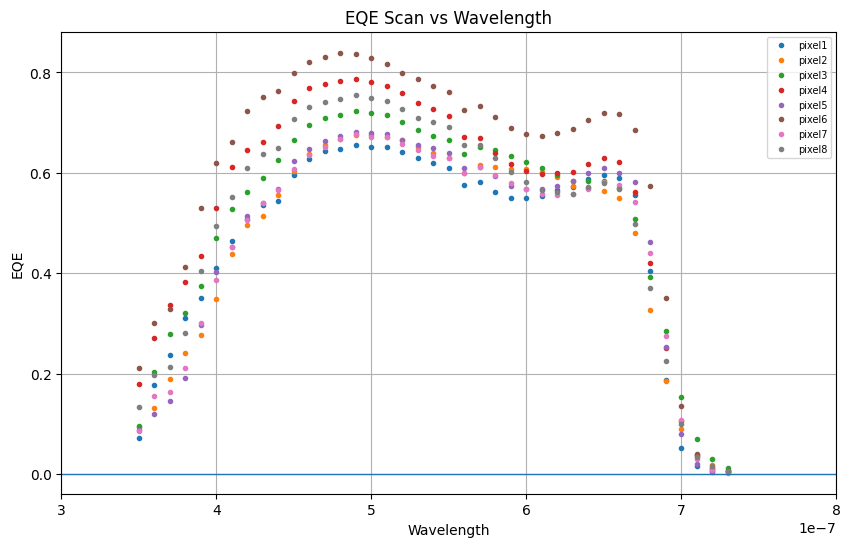

In [12]:
#Mount to google drive to use shared files

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

#Import libraries to do math and build the plots neccesary

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os

# Constants
h = 6.62607015e-34  # Planck's constant (Joule second)
c = 3.0e8  # Speed of light (meters per second)
e = 1.602176634e-19  # Elementary charge (Coulombs)
active_area_cm2 = 0.14  # Active area in cm^2
active_area_m2 = active_area_cm2 * 1e-4  # Convert cm^2 to m^2


# Read the data from the CSV files
powerCell = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week7/EQE_Data/2026_03_10_power_cellR22.csv"
power_data = pd.read_csv(powerCell)

# Convert units
power_W = power_data['Power_mean (uW)'] * 1e-6       # Convert uW to W
folder = "/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week6/EQE_Data"


files = sorted(os.listdir(folder))
eqeData = {}
i = 0

powerData = pd.read_csv("/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week7/EQE_Data/2026_03_10_power_cellR22.csv")
powerW = powerData['Power_mean (uW)'] * 1e-6       # Convert uW to W

for f in files:
  nameList = f.split("_")
  check = nameList[3]

  if check == "power":
    continue
  else:
    name = nameList[5].replace(".csv", "")
    currentData = pd.read_csv(folder + "/" + f)
    currentA = currentData['Current_mean (nA)'] * 1e-9  # Convert nA to A
    wavelengthMeters = currentData['Wavelength (nm)'] * 1e-9  # Convert nm to meters

  eqe = (currentA / powerW) * (h * c / (e * wavelengthMeters))


  eqeColumns = {
      "Wavelength": wavelengthMeters,
      "EQE": eqe.round(4)
  }

  eqeData[name] = pd.DataFrame(eqeColumns);

plt.figure(figsize=(10, 6))

for name, df in eqeData.items():
    plt.plot(df['Wavelength'], df['EQE'], ".", label=name)



plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlim(3 * 1e-7, 8 * 1e-7)
plt.xlabel("Wavelength")
plt.ylabel("EQE")
plt.title("EQE Scan vs Wavelength")
plt.legend(fontsize=7)
plt.grid(True)
plt.show()


# **Save .csv file**

In [13]:
# This code creates a single csv file combining your EQE results for all pixels.
# Update the variable and file names to match your data.

import pandas as pd

# You can use any pixel's current data to get the Wavelength column
# (they all share the same wavelengths)
pix1_current_data = pd.read_csv('/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week7/EQE_Data/2026_03_10_current_cellR22_pixel8.csv')



# Create a combined DataFrame with all pixel EQE values.
# The column names should be 'eqe_pix1', 'eqe_pix2', etc.
# Make sure the variable names match what you calculated in the cell(s) above.

eqe_pix1 = eqeData['pixel1']['EQE']
eqe_pix2 = eqeData['pixel2']['EQE']
eqe_pix3 = eqeData['pixel3']['EQE']
eqe_pix4 = eqeData['pixel4']['EQE']
eqe_pix5 = eqeData['pixel5']['EQE']
eqe_pix6 = eqeData['pixel6']['EQE']
eqe_pix7 = eqeData['pixel7']['EQE']
eqe_pix8 = eqeData['pixel8']['EQE']

eqe_df = pd.DataFrame({
    'Wavelength (nm)': pix1_current_data['Wavelength (nm)'],
    'eqe_pix1': eqe_pix1,
    'eqe_pix2': eqe_pix2,
    'eqe_pix3': eqe_pix3,
    'eqe_pix4': eqe_pix4,
    'eqe_pix5': eqe_pix5,
    'eqe_pix6': eqe_pix6,
    'eqe_pix7': eqe_pix7,
    'eqe_pix8': eqe_pix8,
})

# Write to CSV - update the file name to reflect correct date and cell ID
eqe_df.to_csv('/content/drive/MyDrive/Section 104 Tuesday 2:15 PM Team B/Week7/2026_03_10_eqe_cellR22.csv', index=False)

print("EQE data has been written to 2026_03_03_eqe_cellR22.csv")

# Download the csv files you create to your team Google Drive folder so they
# are easy to access for future weeks

EQE data has been written to 2026_03_03_eqe_cellR22.csv


# **Author Contributions (required)**



1.   List the name of each team member and please describe briefly how each member contributed to the work in lab this week. (e.g., taking a measurement, updating the Colab notebook, etc.)





Jay - Assisted in data collection, interpreted data and responded to reflection questions.

Greg - Assisted in data collection, completed most of the code.

Madelyn - Assisted in data collection, kept time logs.

# **Use of AI (required)**



1.   How your team used AI tools: Describe the specific tasks where AI-assisted tools were involved. For example, did AI help with writing, debugging, optimizing, or refining your code? Which components of the analysis did your team use AI on?
2.   When your team used AI tools: Specify at what stage(s) of your programming process you used AI. Was it during initial code development, troubleshooting, etc.?
3.   Which AI tools your team used: Identify the AI tools or platforms your team consulted (e.g., ChatGPT, GitHub Copilot, etc.).

AI was only used to debug. We used ChatGPT at the end to correct any minor issues. Our code was copied and pasted into the promt box.
